In [1]:
! pip install lpips

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets, transforms
from torchvision.models import inception_v3

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from torchsummary import summary


from PIL import Image
import os
import glob
import time
import random
import warnings

from tqdm.notebook import tqdm
from tabulate import tabulate
from IPython.display import clear_output

from sklearn.metrics.pairwise import cosine_similarity
from scipy import linalg
from skimage.metrics import structural_similarity as ssim

# Suppress warnings
warnings.filterwarnings('ignore')

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

%matplotlib inline

In [4]:
DATA_ROOT = "/kaggle/input/datasets/bryanb/abstract-art-gallery/Abstract_gallery/Abstract_gallery"
LATENT_DIM = 100
IMG_SIZE = 28
IMG_FLAT = 28 * 28 * 1
HIDDEN_DIM = 256
BATCH_SIZE = 128
LR_G = 2e-4
LR_D = 5e-5
BETAS = (0.5, 0.999)
EPOCHS = 200
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# Get all image files
image_files = glob.glob(os.path.join(DATA_ROOT, '**', '*.png'), recursive=True)

# Randomly select 25 images
random.shuffle(image_files)
selected_files = image_files[:25]

# Plot 5x5 grid
plt.figure(figsize=(10, 10))

for i, filename in enumerate(selected_files):
    img_path = os.path.join(DATA_ROOT, filename)
    img = Image.open(img_path).resize((28,28))   # resize to match your IMG_SIZE
    
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.axis('off')

plt.tight_layout()
plt.show()

<Figure size 1000x1000 with 0 Axes>

In [6]:
DATA_ROOT = "/kaggle/input/datasets/wchowdhu/bengali-digits/bengali_digits"

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset    = datasets.ImageFolder(root=DATA_ROOT, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"Total images : {len(dataset)}")
print(f"Classes      : {dataset.classes}")
print(f"IMG_FLAT     : {IMG_FLAT}")

Total images : 15620
Classes      : ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
IMG_FLAT     : 784


# Why We Changed Sigmoid → Tanh in Generator

## Original Paper (Goodfellow 2014):
> The paper used Sigmoid as the output activation because they tested on MNIST which is a binary-like image — pixels are either black or white.
```
Sigmoid output: [0, 1]   ← works for binary images
```

## Problem with Sigmoid on real datasets:

```
Sigmoid squashes output to [0, 1]
At extremes (near 0 or 1) → gradient becomes ~0
Zero gradient → G stops learning → vanishing gradient
```

## This is exactly what we saw:

```
D(G(z)) stuck at 0.10
Loss_G  stuck at 2.30
Images  → random noise (QR code pattern)
```

## Why Tanh fixes it:

```
Tanh output: [-1, 1]
Centered at 0        → balanced gradients
Stronger gradients   → G keeps learning
Matches Normalize    → [-1,1] = [-1,1] 
```
## Visual comparison:

```
Sigmoid:          Tanh:
    1 |___         1 |    ___
      |   \          |   /
    0 |____\___    0 |__/________
                  -1 |
                  
Flat at edges      Steep everywhere
= dead gradients   = active gradients

```

## Simple analogy:

> Sigmoid is like a student who gives up after failing — stops trying. Tanh is like a student who keeps trying even after failure — never gives up learning.

# Building the Generator


In [7]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM * 4),
            nn.LeakyReLU(0.2),
            
            nn.Linear(HIDDEN_DIM * 4, IMG_FLAT),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.net(z)
        img = img.view(-1, 1, IMG_SIZE, IMG_SIZE)
        return img

generator = Generator().to(DEVICE)
summary(generator, input_size=(LATENT_DIM,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]          25,856
         LeakyReLU-2                  [-1, 256]               0
            Linear-3                  [-1, 512]         131,584
         LeakyReLU-4                  [-1, 512]               0
            Linear-5                 [-1, 1024]         525,312
         LeakyReLU-6                 [-1, 1024]               0
            Linear-7                  [-1, 784]         803,600
              Tanh-8                  [-1, 784]               0
Total params: 1,486,352
Trainable params: 1,486,352
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 5.67
Estimated Total Size (MB): 5.71
----------------------------------------------------------------


# Building the Discriminator

In [8]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(IMG_FLAT, HIDDEN_DIM * 4),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM * 4, HIDDEN_DIM * 2),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM * 2, HIDDEN_DIM),
            nn.LeakyReLU(0.2),
            nn.Linear(HIDDEN_DIM, 1)
        )

    def forward(self, img):
        img = img.view(-1, IMG_FLAT)
        return self.net(img)

D = Discriminator().to(DEVICE)
summary(D, input_size=(IMG_FLAT,))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [-1, 1024]         803,840
         LeakyReLU-2                 [-1, 1024]               0
            Linear-3                  [-1, 512]         524,800
         LeakyReLU-4                  [-1, 512]               0
            Linear-5                  [-1, 256]         131,328
         LeakyReLU-6                  [-1, 256]               0
            Linear-7                    [-1, 1]             257
Total params: 1,460,225
Trainable params: 1,460,225
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 5.57
Estimated Total Size (MB): 5.60
----------------------------------------------------------------


In [9]:
G = Generator().to(DEVICE)
D = Discriminator().to(DEVICE)
opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=BETAS)
criterion = nn.BCEWithLogitsLoss()
fixed_noise = torch.randn(25, LATENT_DIM, device=DEVICE)

In [10]:
history = {'epoch': [], 'loss_D': [], 'loss_G': [],'D_x': [], 'D_G_z1': [], 'D_G_z2': []}

def sample(epoch, loss_D, loss_G):
    G.eval()
    with torch.no_grad():
        imgs = G(fixed_noise).cpu()
        imgs = (imgs + 1) / 2  
        imgs = imgs.clamp(0, 1)
    G.train()
    fig, axes = plt.subplots(5, 5, figsize=(10, 10))
    fig.patch.set_facecolor('#0d0d0d')
    for ax, img in zip(axes.flatten(), imgs):
        ax.imshow(img.squeeze().numpy(), cmap='gray')  
        ax.axis('off')
        for spine in ax.spines.values():
            spine.set_edgecolor('#333')
    fig.suptitle(
        f'Epoch {epoch}/{EPOCHS}   |   Loss_D: {loss_D:.4f}   |   Loss_G: {loss_G:.4f}',
        color='white', fontsize=13, fontweight='bold', y=0.98
    )
    plt.tight_layout()
    plt.savefig(f'samples_epoch_{epoch:03d}.png', dpi=120,
                bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print()



def print_table():
    rows = list(zip(
        history['epoch'], history['loss_D'], history['loss_G'],
        history['D_x'], history['D_G_z1'], history['D_G_z2']
    ))
    rows = rows[-10:]
    rows = [[e, f'{ld:.4f}', f'{lg:.4f}', f'{dx:.4f}',
             f'{dg1:.4f}', f'{dg2:.4f}'] for e, ld, lg, dx, dg1, dg2 in rows]
    print(tabulate(
        rows,
        headers=['Epoch', 'Loss_D', 'Loss_G', 'D(x)', 'D(G(z)) before', 'D(G(z)) after'],
        tablefmt='fancy_grid',
        numalign='center'
    ))

In [11]:
def train():
    print("=" * 70)
    print(f"  Vanilla GAN — Bengali Digits | Device: {DEVICE}")
    print(f"  Epochs: {EPOCHS} | Batch Size: {BATCH_SIZE} | LR_G: {LR_G} | LR_D: {LR_D}")
    print("=" * 70)
    print()
    epoch_pbar = tqdm(
        range(1, EPOCHS + 1),
        desc="Training Progress",
        unit="epoch",
        colour="green",
        position=0,
        leave=True,
        dynamic_ncols=True,
        bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}, {rate_fmt}]"
    )
    for epoch in epoch_pbar:
        sum_loss_D = sum_loss_G = 0.0
        sum_D_x = sum_D_G_z1 = sum_D_G_z2 = 0.0
        n_batches = 0
        start = time.time()
        batch_pbar = tqdm(
            dataloader,
            desc=f"Epoch {epoch:3d}",
            unit="batch",
            colour="cyan",
            position=1,
            leave=False,
            dynamic_ncols=True,
            bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} [{elapsed}<{remaining}]"
        )
        for real_imgs in batch_pbar:
            if isinstance(real_imgs, (list, tuple)):
                real_imgs = real_imgs[0]
            real_imgs = real_imgs.to(DEVICE)
            bs = real_imgs.size(0)
            real_labels = torch.full((bs, 1), 0.9, device=DEVICE)
            fake_labels = torch.full((bs, 1), 0.1, device=DEVICE)

            # ── Train Discriminator ────────────────────────────────────────
            z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake_imgs = G(z).detach()
            D_real    = D(real_imgs.view(bs, -1))
            D_fake    = D(fake_imgs.view(bs, -1))
            loss_D    = (criterion(D_real, real_labels) + criterion(D_fake, fake_labels)) / 2
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # ── Train Generator ────────────────────────────────────────────
            z         = torch.randn(bs, LATENT_DIM, device=DEVICE)
            fake_imgs = G(z)
            D_fake2   = D(fake_imgs.view(bs, -1))
            loss_G    = criterion(D_fake2, torch.ones(bs, 1, device=DEVICE))
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            sum_loss_D += loss_D.item()
            sum_loss_G += loss_G.item()
            sum_D_x    += D_real.mean().item()
            sum_D_G_z1 += D_fake.mean().item()
            sum_D_G_z2 += D_fake2.mean().item()
            n_batches  += 1
            batch_pbar.set_postfix({
                'Loss_D' : f'{loss_D.item():.4f}',
                'Loss_G' : f'{loss_G.item():.4f}',
                'D(x)'   : f'{D_real.mean().item():.4f}',
                'D(G(z))': f'{D_fake2.mean().item():.4f}'
            })
        avg_loss_D = sum_loss_D / n_batches
        avg_loss_G = sum_loss_G / n_batches
        avg_D_x    = sum_D_x    / n_batches
        avg_D_G_z1 = sum_D_G_z1 / n_batches
        avg_D_G_z2 = sum_D_G_z2 / n_batches
        elapsed    = time.time() - start
        history['epoch'].append(epoch)
        history['loss_D'].append(avg_loss_D)
        history['loss_G'].append(avg_loss_G)
        history['D_x'].append(avg_D_x)
        history['D_G_z1'].append(avg_D_G_z1)
        history['D_G_z2'].append(avg_D_G_z2)
        epoch_pbar.set_postfix({
            'Loss_D': f'{avg_loss_D:.4f}',
            'Loss_G': f'{avg_loss_G:.4f}',
            'D(x)'  : f'{avg_D_x:.4f}',
            'Time'  : f'{elapsed:.1f}s'
        })
        clear_output(wait=True)
        print_table()
        sample(epoch, avg_loss_D, avg_loss_G)
    print("\nTraining complete!")


╒═════════╤══════════╤══════════╤════════╤══════════════════╤═════════════════╕
│  Epoch  │  Loss_D  │  Loss_G  │  D(x)  │  D(G(z)) before  │  D(G(z)) after  │
╞═════════╪══════════╪══════════╪════════╪══════════════════╪═════════════════╡
│   191   │  0.4608  │  1.6922  │ 1.4128 │     -1.3243      │     -1.3959     │
├─────────┼──────────┼──────────┼────────┼──────────────────┼─────────────────┤
│   192   │  0.4556  │  1.6959  │ 1.4225 │     -1.3402      │     -1.4052     │
├─────────┼──────────┼──────────┼────────┼──────────────────┼─────────────────┤
│   193   │  0.4587  │  1.6938  │ 1.4207 │     -1.3333      │     -1.4006     │
├─────────┼──────────┼──────────┼────────┼──────────────────┼─────────────────┤
│   194   │  0.4555  │  1.6995  │ 1.4262 │     -1.3323      │     -1.4144     │
├─────────┼──────────┼──────────┼────────┼──────────────────┼─────────────────┤
│   195   │  0.4582  │  1.7121  │ 1.4215 │     -1.3425      │     -1.4224     │
├─────────┼──────────┼──────────┼───────

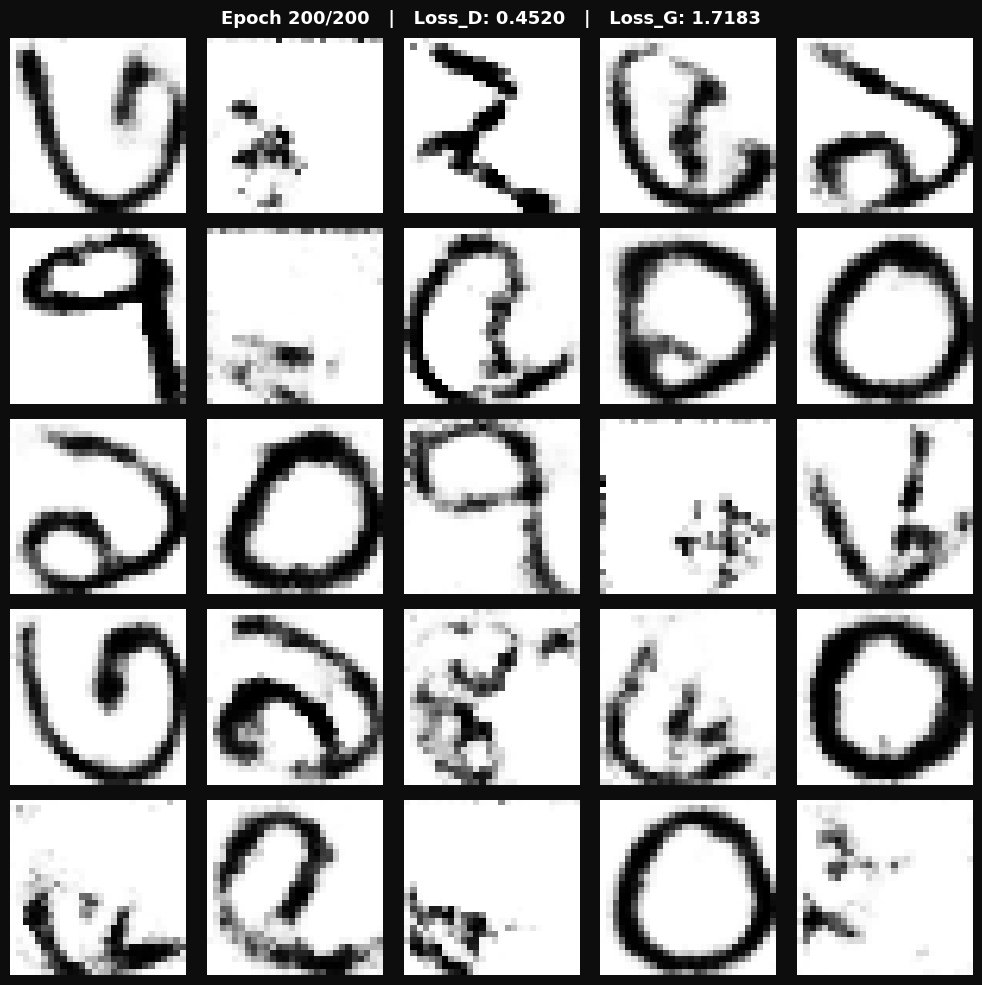



Training complete!


In [12]:
train()

In [13]:
def plot_training_history():
    epochs = history['epoch']
    loss_D = history['loss_D']
    loss_G = history['loss_G']
    D_x = history['D_x']
    D_G_z1 = history['D_G_z1']
    D_G_z2 = history['D_G_z2']

    plt.style.use('dark_background')
    fig = plt.figure(figsize=(18, 12))
    fig.patch.set_facecolor('#0d0d0d')
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

    COLORS = {
        'D': '#00e5ff',
        'G': '#ff4081',
        'Dx': '#69ff47',
        'DGz1': '#ff9100',
        'DGz2': '#d500f9',
        'grid': '#1e1e1e',
        'text': '#e0e0e0',
    }

    def style_ax(ax, title):
        ax.set_facecolor('#111111')
        ax.set_title(title, color=COLORS['text'], fontsize=12, fontweight='bold', pad=10)
        ax.tick_params(colors=COLORS['text'], labelsize=9)
        ax.xaxis.label.set_color(COLORS['text'])
        ax.yaxis.label.set_color(COLORS['text'])
        for spine in ax.spines.values():
            spine.set_edgecolor('#333333')
        ax.grid(color=COLORS['grid'], linestyle='--', linewidth=0.6, alpha=0.7)
        ax.set_xlabel('Epoch', fontsize=10)

    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(epochs, loss_D, color=COLORS['D'], linewidth=2, label='Loss_D', marker='o', markersize=3)
    ax1.plot(epochs, loss_G, color=COLORS['G'], linewidth=2, label='Loss_G', marker='o', markersize=3)
    ax1.fill_between(epochs, loss_D, alpha=0.1, color=COLORS['D'])
    ax1.fill_between(epochs, loss_G, alpha=0.1, color=COLORS['G'])
    ax1.axhline(y=0.693, color='white', linestyle=':', linewidth=1, alpha=0.5, label='Nash Eq (ln2)')
    ax1.set_ylabel('Loss', fontsize=10)
    ax1.legend(fontsize=9, facecolor='#1e1e1e', edgecolor='#444', labelcolor=COLORS['text'])
    style_ax(ax1, 'Generator & Discriminator Loss')

    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(epochs, D_x, color=COLORS['Dx'], linewidth=2, marker='o', markersize=3, label='D(x)')
    ax2.fill_between(epochs, D_x, alpha=0.15, color=COLORS['Dx'])
    ax2.axhline(y=0.5, color='white', linestyle=':', linewidth=1, alpha=0.5, label='Ideal = 0.5')
    ax2.set_ylim(0, 1)
    ax2.set_ylabel('Probability', fontsize=10)
    ax2.legend(fontsize=9, facecolor='#1e1e1e', edgecolor='#444', labelcolor=COLORS['text'])
    style_ax(ax2, 'D(x) - Real Image Confidence')

    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(epochs, D_G_z1, color=COLORS['DGz1'], linewidth=2, marker='o', markersize=3, label='D(G(z)) before')
    ax3.plot(epochs, D_G_z2, color=COLORS['DGz2'], linewidth=2, marker='o', markersize=3, label='D(G(z)) after')
    ax3.fill_between(epochs, D_G_z1, alpha=0.1, color=COLORS['DGz1'])
    ax3.fill_between(epochs, D_G_z2, alpha=0.1, color=COLORS['DGz2'])
    ax3.axhline(y=0.5, color='white', linestyle=':', linewidth=1, alpha=0.5, label='Ideal = 0.5')
    ax3.set_ylim(0, 1)
    ax3.set_ylabel('Probability', fontsize=10)
    ax3.legend(fontsize=9, facecolor='#1e1e1e', edgecolor='#444', labelcolor=COLORS['text'])
    style_ax(ax3, 'D(G(z)) Before & After G Update')

    ax4 = fig.add_subplot(gs[1, 0])
    diff = [g - d for g, d in zip(loss_G, loss_D)]
    colors_bar = [COLORS['G'] if v > 0 else COLORS['D'] for v in diff]
    ax4.bar(epochs, diff, color=colors_bar, alpha=0.8, width=0.6)
    ax4.axhline(y=0, color='white', linestyle='-', linewidth=0.8, alpha=0.5)
    ax4.set_ylabel('Loss_G - Loss_D', fontsize=10)
    style_ax(ax4, 'Loss Gap (G - D)')

    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(epochs, D_x, color=COLORS['Dx'], linewidth=2, label='D(x) real', marker='o', markersize=3)
    ax5.plot(epochs, D_G_z2, color=COLORS['DGz2'], linewidth=2, label='D(G(z)) fake', marker='o', markersize=3)
    ax5.fill_between(epochs, D_x, D_G_z2, alpha=0.08, color='white', label='Gap')
    ax5.axhline(y=0.5, color='white', linestyle=':', linewidth=1, alpha=0.5)
    ax5.set_ylim(0, 1)
    ax5.set_ylabel('Probability', fontsize=10)
    ax5.legend(fontsize=9, facecolor='#1e1e1e', edgecolor='#444', labelcolor=COLORS['text'])
    style_ax(ax5, 'Real vs Fake Confidence Gap')

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.axis('off')
    ax6.set_facecolor('#111111')

    final_loss_D = loss_D[-1]
    final_loss_G = loss_G[-1]
    final_Dx = D_x[-1]
    final_DGz = D_G_z2[-1]
    balance = abs(final_Dx - final_DGz)

    def health(val, good, warn):
        if val <= good: return 'Good'
        if val <= warn: return 'Warn'
        return 'Bad'

    rows = [
        ['Loss_D (final)', f'{final_loss_D:.4f}', health(final_loss_D, 0.5, 0.9)],
        ['Loss_G (final)', f'{final_loss_G:.4f}', health(final_loss_G, 1.5, 3.0)],
        ['D(x) (final)', f'{final_Dx:.4f}', 'Good' if 0.4 < final_Dx < 0.8 else 'Warn'],
        ['D(G(z)) (final)', f'{final_DGz:.4f}', 'Good' if 0.2 < final_DGz < 0.6 else 'Warn'],
        ['Real/Fake Balance', f'{balance:.4f}', 'Good' if balance < 0.3 else 'Bad'],
        ['Total Epochs', f'{epochs[-1]}', 'Done'],
    ]

    table = ax6.table(
        cellText=rows,
        colLabels=['Metric', 'Value', 'Status'],
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (r, c), cell in table.get_celld().items():
        cell.set_facecolor('#1a1a1a' if r % 2 == 0 else '#111111')
        cell.set_text_props(color=COLORS['text'])
        cell.set_edgecolor('#333333')
        if r == 0:
            cell.set_facecolor('#222222')
            cell.set_text_props(color='white', fontweight='bold')

    style_ax(ax6, 'Training Health Summary')

    fig.suptitle(
        'Vanilla GAN - Abstract Art Gallery | Training Report',
        color='white', fontsize=15, fontweight='bold', y=1.01
    )

    plt.savefig('gan_training_report.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0d')
    plt.show()
    print("Saved -> gan_training_report.png")

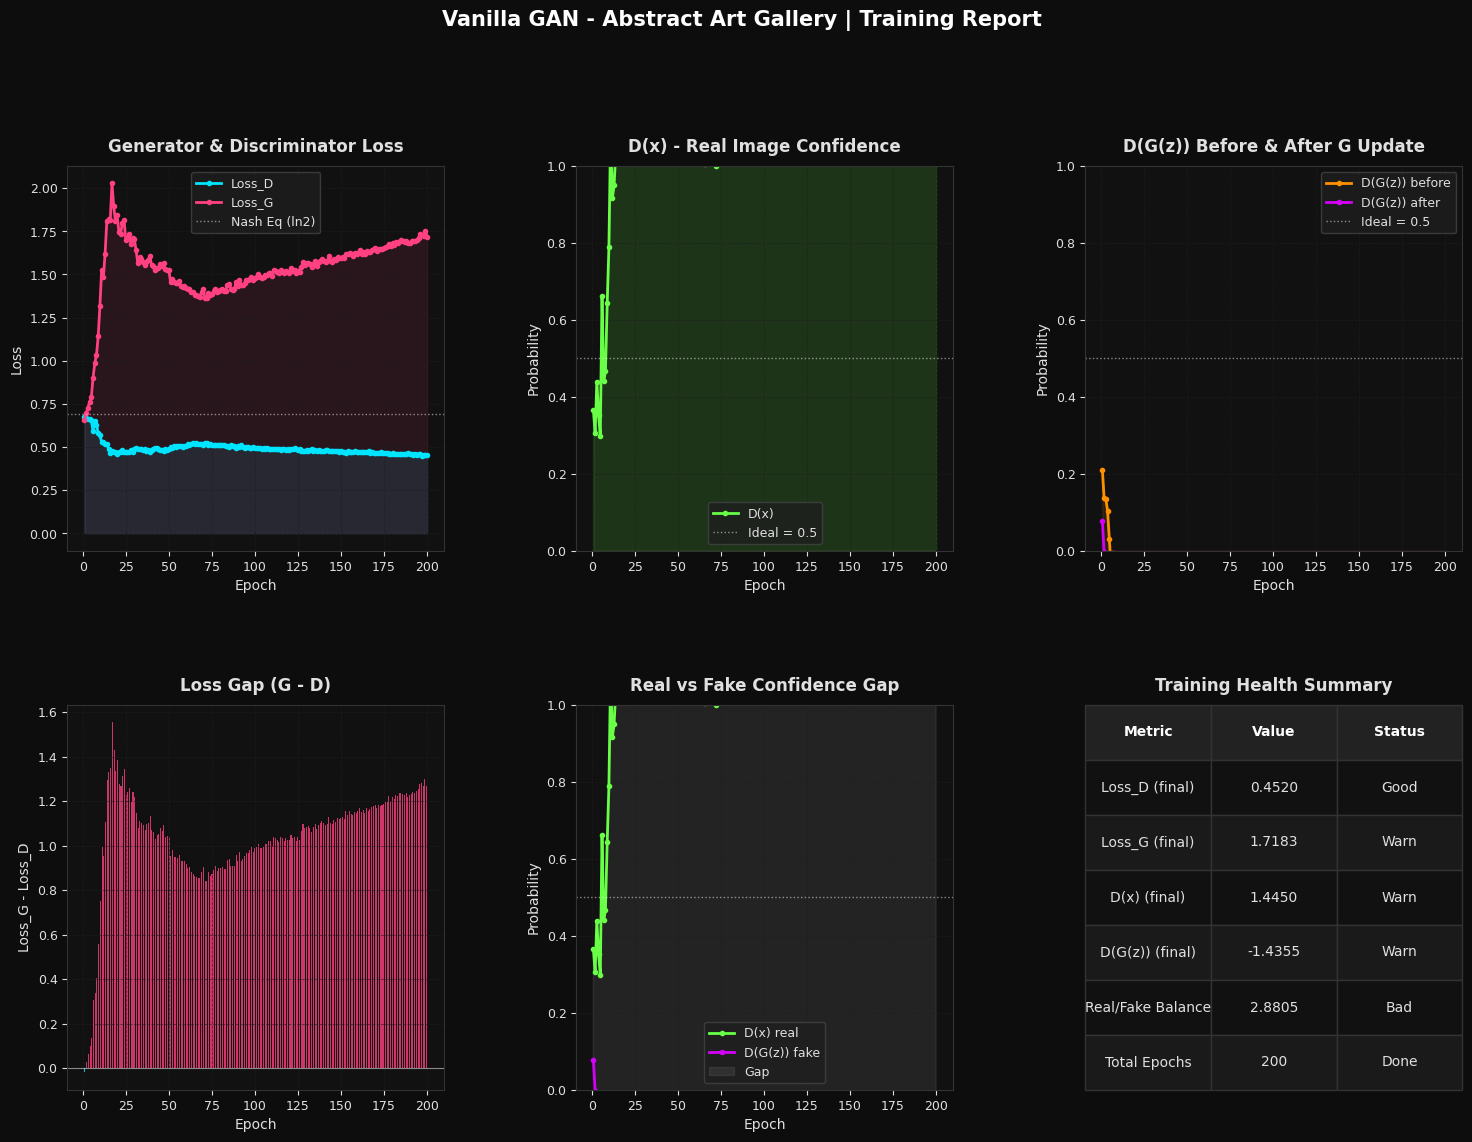

Saved -> gan_training_report.png


In [14]:
plot_training_history()

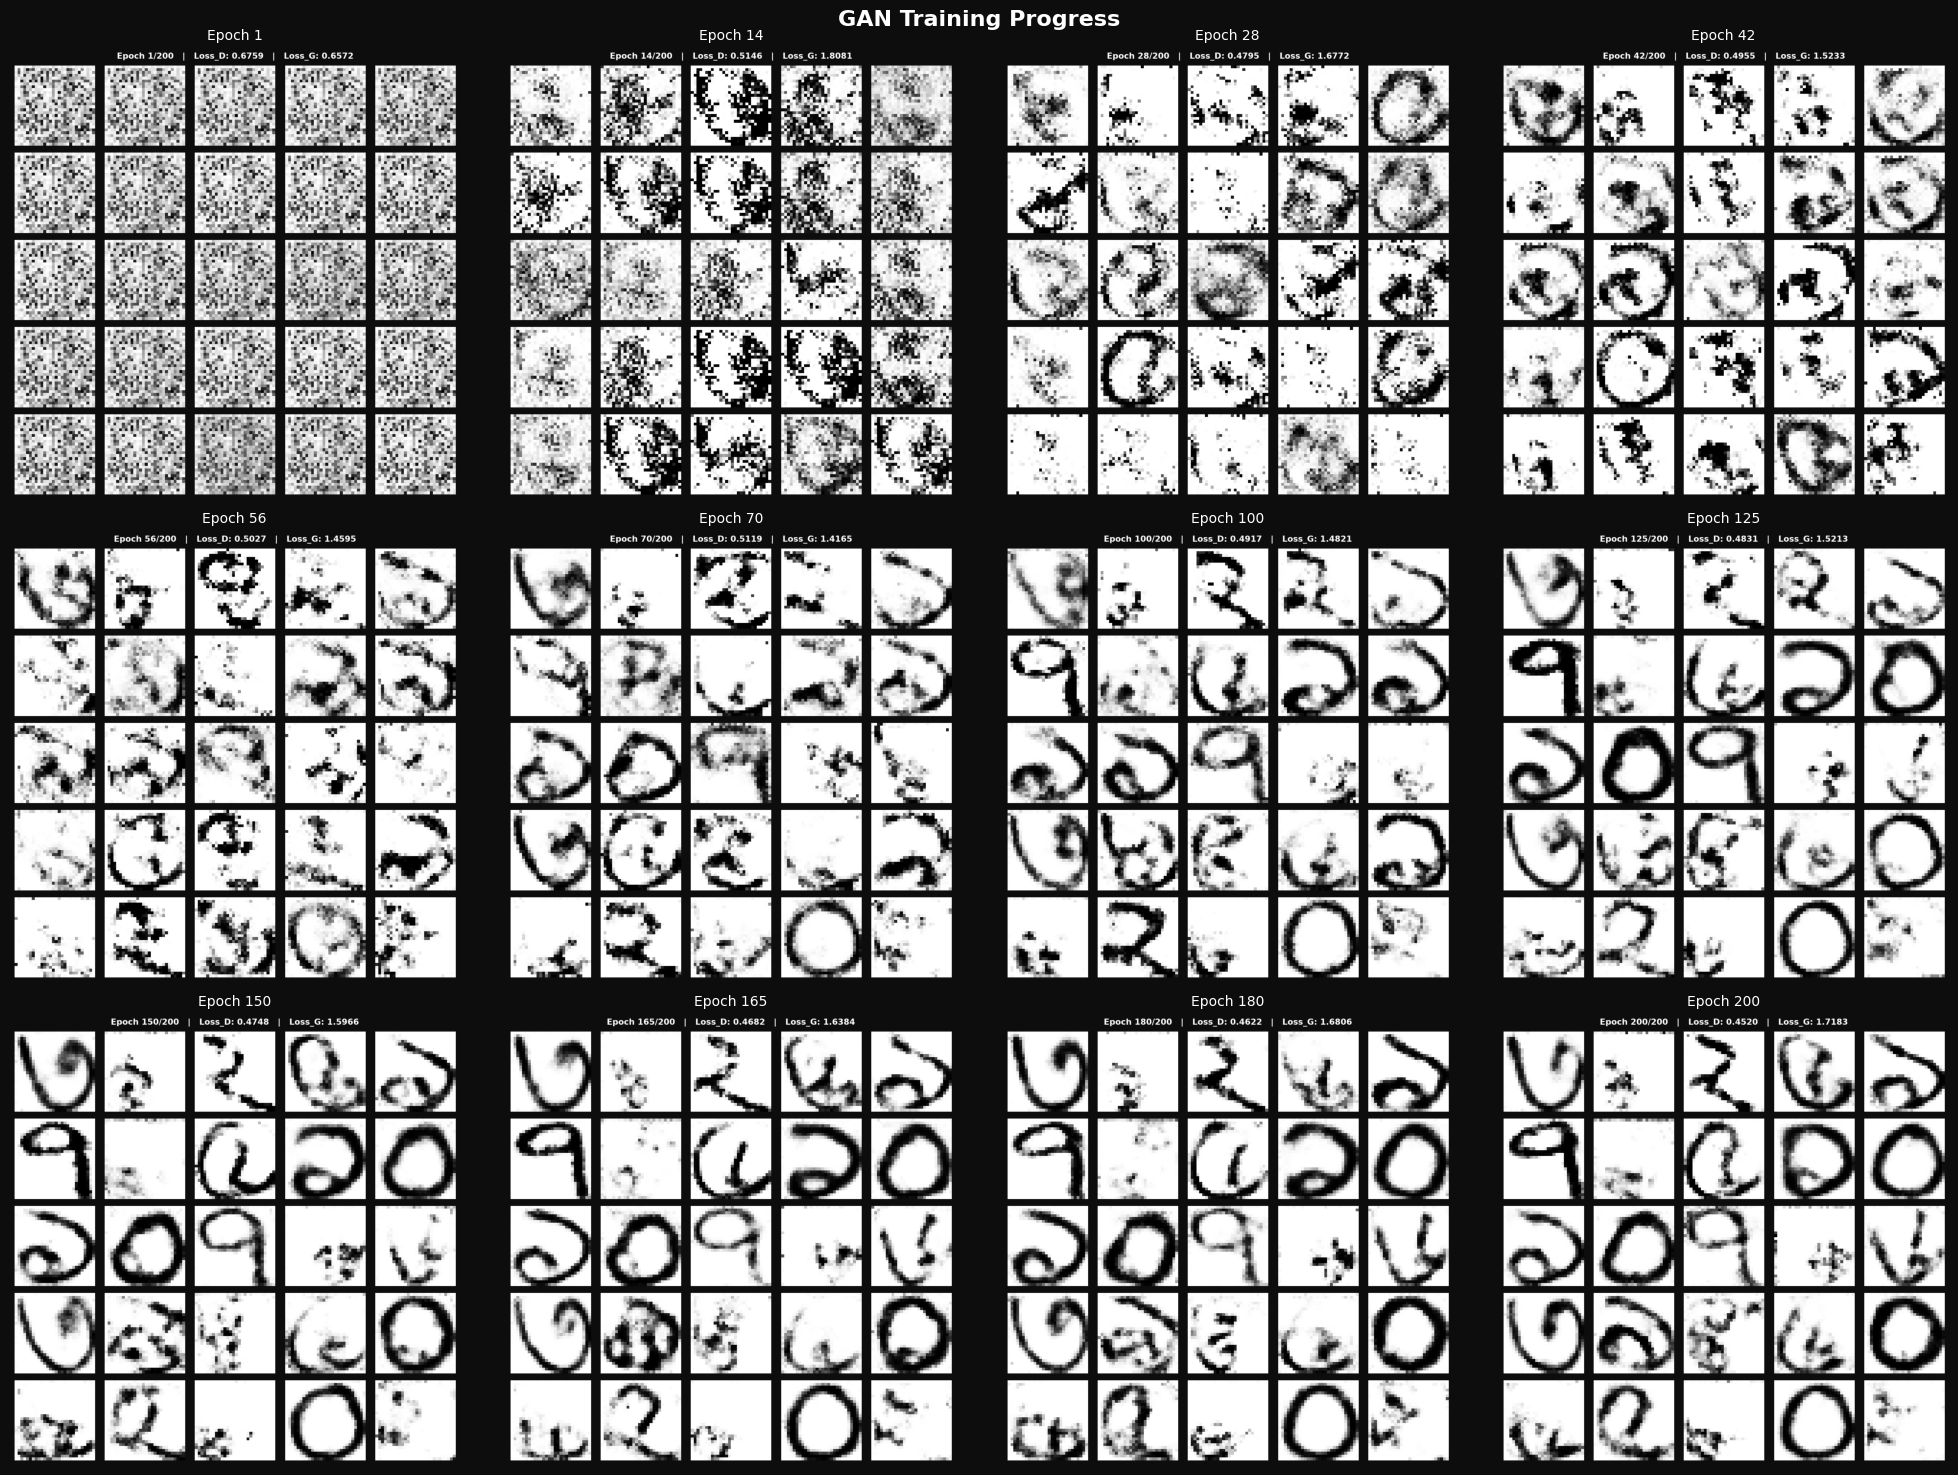

In [15]:
saved = sorted(glob.glob("samples_epoch_*.png"))
epochs_to_show = [1, 14, 28, 42, 56, 70, 100, 125, 150, 165, 180, 200]
files = [f for f in saved if int(f.split('_')[-1].replace('.png', '')) in epochs_to_show]
files = files if files else saved[::max(1, len(saved)//12)][:12]

fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.patch.set_facecolor('#0d0d0d')

for ax, fpath in zip(axes.flatten(), files):
    epoch_num = int(fpath.split('_')[-1].replace('.png', ''))
    img = plt.imread(fpath)
    ax.imshow(img)
    ax.set_title(f'Epoch {epoch_num}', color='white', fontsize=10)
    ax.axis('off')

for ax in axes.flatten()[len(files):]:
    ax.axis('off')

plt.suptitle("GAN Training Progress", color='white', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# Generate Fake Images
def generate_fake(n=1000):
    G.eval()
    imgs = []
    with torch.no_grad():
        for i in range(0, n, 128):
            bs = min(128, n - i)
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            out = G(z).cpu()
            imgs.append(out)
    return torch.cat(imgs, dim=0)


# Get Real Images
def get_real(n=1000):
    imgs = []
    for batch, _ in dataloader:
        imgs.append(batch)
        if torch.cat(imgs).shape[0] >= n:
            break
    return torch.cat(imgs)[:n]



# Image Processing Helpers
def to_rgb_3ch(imgs):
    if imgs.shape[1] == 1:
        imgs = imgs.repeat(1, 3, 1, 1)
    return imgs

def denorm(imgs):
    return (imgs + 1) / 2.0

def resize_for_inception(imgs, size=75):
    return F.interpolate(imgs, size=(size, size), mode='bilinear', align_corners=False)


# Inception Features
def get_inception_features(imgs, model, batch_size=64):
    model.eval()
    feats = []
    imgs = resize_for_inception(to_rgb_3ch(denorm(imgs)))
    ds = TensorDataset(imgs)
    dl = DataLoader(ds, batch_size=batch_size)
    with torch.no_grad():
        for (x,) in dl:
            x = x.to(DEVICE)
            f = model(x)
            feats.append(f.cpu().numpy())
    return np.concatenate(feats, axis=0)



# FID Score
def compute_fid(real_feats, fake_feats):
    mu1, sigma1 = real_feats.mean(0), np.cov(real_feats, rowvar=False)
    mu2, sigma2 = fake_feats.mean(0), np.cov(fake_feats, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = linalg.sqrtm(sigma1 @ sigma2, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean))

In [17]:
# KID Score
def compute_kid(real_feats, fake_feats, num_subsets=10, subset_size=100):
    scores = []
    for _ in range(num_subsets):
        r = real_feats[np.random.choice(len(real_feats), subset_size, replace=False)]
        f = fake_feats[np.random.choice(len(fake_feats), subset_size, replace=False)]
        k_rr = r @ r.T / r.shape[1]
        k_ff = f @ f.T / f.shape[1]
        k_rf = r @ f.T / r.shape[1]
        scores.append(k_rr.mean() + k_ff.mean() - 2 * k_rf.mean())
    return float(np.mean(scores)), float(np.std(scores))


# Inception Score
def compute_is(imgs, model_is, splits=5):
    model_is.eval()
    preds = []
    imgs_r = resize_for_inception(to_rgb_3ch(denorm(imgs)))
    ds = TensorDataset(imgs_r)
    dl = DataLoader(ds, batch_size=64)
    with torch.no_grad():
        for (x,) in dl:
            x = x.to(DEVICE)
            p = torch.softmax(model_is(x), dim=1).cpu().numpy()
            preds.append(p)
    preds = np.concatenate(preds, axis=0)
    scores = []
    n = preds.shape[0]
    for i in range(splits):
        part = preds[i * n // splits:(i + 1) * n // splits]
        py = part.mean(axis=0)
        scores.append(np.exp(np.mean(np.sum(part * (np.log(part + 1e-10) - np.log(py + 1e-10)), axis=1))))
    return float(np.mean(scores)), float(np.std(scores))



# SSIM and MS-SSIM
def compute_ssim(real_imgs, fake_imgs, n=200):
    scores = []
    r = denorm(real_imgs[:n]).numpy()
    f = denorm(fake_imgs[:n]).numpy()
    for i in range(n):
        ri = r[i, 0]
        fi = f[i, 0]
        scores.append(ssim(ri, fi, data_range=1.0))
    return float(np.mean(scores)), float(np.std(scores))

def compute_ms_ssim(fake_imgs, n=200):
    from pytorch_msssim import ms_ssim
    f = denorm(fake_imgs[:n]).to(DEVICE)
    f3 = to_rgb_3ch(f)
    pairs = []
    for i in range(0, n - 1, 2):
        pairs.append(ms_ssim(f3[i:i+1], f3[i+1:i+2], data_range=1.0).item())
    return float(np.mean(pairs)), float(np.std(pairs))



# Discriminator Accuracy
def compute_disc_accuracy(real_imgs, fake_imgs):
    D.eval()
    with torch.no_grad():
        r = torch.sigmoid(D(real_imgs.view(len(real_imgs), -1).to(DEVICE))).cpu().numpy()
        f = torch.sigmoid(D(fake_imgs.view(len(fake_imgs), -1).detach().to(DEVICE))).cpu().numpy()
    real_acc = (r >= 0.5).mean() * 100
    fake_acc = (f < 0.5).mean() * 100
    overall  = ((r >= 0.5).sum() + (f < 0.5).sum()) / (len(r) + len(f)) * 100
    D.train()
    return real_acc, fake_acc, overall

In [18]:
# Precision & Recall
def compute_precision_recall(real_feats, fake_feats, k=3):
    from sklearn.neighbors import NearestNeighbors
    nbrs_real = NearestNeighbors(n_neighbors=k+1).fit(real_feats)
    nbrs_fake = NearestNeighbors(n_neighbors=k+1).fit(fake_feats)
    real_dist, _ = nbrs_real.kneighbors(real_feats)
    fake_dist, _ = nbrs_fake.kneighbors(fake_feats)
    real_r = real_dist[:, -1]
    fake_r = fake_dist[:, -1]
    dist_rf, _ = nbrs_real.kneighbors(fake_feats, n_neighbors=k)
    dist_fr, _ = nbrs_fake.kneighbors(real_feats, n_neighbors=k)
    precision = (dist_rf.min(axis=1) <= real_r[np.argmin(
        np.abs(np.arange(len(real_r))[:, None] - np.arange(len(fake_feats))[None, :]), axis=0
    )]).mean()
    recall = (dist_fr.min(axis=1) <= fake_r[np.argmin(
        np.abs(np.arange(len(fake_r))[:, None] - np.arange(len(real_feats))[None, :]), axis=0
    )]).mean()
    return float(precision), float(recall)



# LPIPS + Run All Metrics
def compute_lpips(real_imgs, fake_imgs, n=200):
    import lpips
    loss_fn = lpips.LPIPS(net='alex').to(DEVICE)
    scores = []
    r = denorm(real_imgs[:n]).to(DEVICE)
    f = denorm(fake_imgs[:n]).to(DEVICE)
    r3 = F.interpolate(to_rgb_3ch(r), size=(64, 64), mode='bilinear', align_corners=False) * 2 - 1
    f3 = F.interpolate(to_rgb_3ch(f), size=(64, 64), mode='bilinear', align_corners=False) * 2 - 1
    with torch.no_grad():
        for i in range(0, n, 32):
            scores.append(loss_fn(r3[i:i+32], f3[i:i+32]).mean().item())
    return float(np.mean(scores))

# Run All

In [19]:
print("Computing metrics...")
N = 1000
real_imgs = get_real(N)
fake_imgs = generate_fake(N)

inception_feat = inception_v3(pretrained=True, transform_input=False)
inception_feat.fc = torch.nn.Identity()
inception_feat = inception_feat.to(DEVICE).eval()

inception_is = inception_v3(pretrained=True, transform_input=False).to(DEVICE).eval()

print("Extracting inception features...")
real_feats = get_inception_features(real_imgs, inception_feat)
fake_feats = get_inception_features(fake_imgs, inception_feat)

fid               = compute_fid(real_feats, fake_feats)
kid_mean, kid_std = compute_kid(real_feats, fake_feats)
is_mean,  is_std  = compute_is(fake_imgs, inception_is)
ssim_mean, ssim_std = compute_ssim(real_imgs, fake_imgs)
real_acc, fake_acc, overall_acc = compute_disc_accuracy(real_imgs, fake_imgs)
precision, recall = compute_precision_recall(real_feats, fake_feats)
lpips_score       = compute_lpips(real_imgs, fake_imgs)

try:
    ms_ssim_mean, ms_ssim_std = compute_ms_ssim(fake_imgs)
except:
    ms_ssim_mean, ms_ssim_std = 0.0, 0.0

sep = "=" * 45

print(sep)
print("  FID Score")
print(sep)
print(f"  FID : {fid:.4f}")
print(sep)
print("  < 10  → Excellent")
print("  10-50 → Good")
print("  > 50  → Poor")

print()
print(sep)
print("  KID Score")
print(sep)
print(f"  KID Mean : {kid_mean:.4f}")
print(f"  KID Std  : {kid_std:.4f}")
print(sep)
print("  ~0.0  → Excellent")
print("  > 0.1 → Poor")

print()
print(sep)
print("  Inception Score")
print(sep)
print(f"  IS Mean : {is_mean:.4f}")
print(f"  IS Std  : {is_std:.4f}")
print(sep)
print("  > 3.0 → Good for simple datasets")
print("  > 7.0 → Excellent (ImageNet level)")

print()
print(sep)
print("  SSIM Score")
print(sep)
print(f"  SSIM Mean : {ssim_mean:.4f}")
print(f"  SSIM Std  : {ssim_std:.4f}")
print(sep)
print("  > 0.9   → Excellent")
print("  0.7-0.9 → Good")
print("  0.5-0.7 → Fair")
print("  < 0.5   → Poor")

print()
print(sep)
print("  MS-SSIM Score")
print(sep)
print(f"  MS-SSIM Mean : {ms_ssim_mean:.4f}")
print(f"  MS-SSIM Std  : {ms_ssim_std:.4f}")
print(sep)
print("  > 0.9   → Excellent")
print("  0.7-0.9 → Good")
print("  0.5-0.7 → Fair")
print("  < 0.5   → Poor")

print()
print(sep)
print("  LPIPS Score")
print(sep)
print(f"  LPIPS : {lpips_score:.4f}")
print(sep)
print("  ~0.0  → Identical images")
print("  > 0.5 → Very different")

print()
print(sep)
print("  Discriminator Accuracy")
print(sep)
print(f"  Real Accuracy    : {real_acc:.2f}%")
print(f"  Fake Accuracy    : {fake_acc:.2f}%")
print(f"  Overall Accuracy : {overall_acc:.2f}%")
print(sep)
print("  Real Acc ~50%  → Discriminator confused by real images")
print("  Fake Acc ~50%  → Discriminator confused by fake images")
print("  Both ~50%      → Generator is fooling discriminator")
print("  Both ~100%     → Generator has collapsed")

print()
print(sep)
print("  Precision & Recall")
print(sep)
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(sep)
print("  Precision → How realistic the generated images are")
print("  Recall    → How diverse the generated images are")
print("  Both ~1.0  → Excellent quality & diversity")
print("  Low Prec   → Fake images look unrealistic")
print("  Low Recall → Generator lacks diversity (mode collapse)")

Computing metrics...
Extracting inception features...
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
  FID Score
  FID : 167.6629
  < 10  → Excellent
  10-50 → Good
  > 50  → Poor

  KID Score
  KID Mean : 0.0285
  KID Std  : 0.0044
  ~0.0  → Excellent
  > 0.1 → Poor

  Inception Score
  IS Mean : 1.6996
  IS Std  : 0.0801
  > 3.0 → Good for simple datasets
  > 7.0 → Excellent (ImageNet level)

  SSIM Score
  SSIM Mean : 0.1042
  SSIM Std  : 0.1429
  > 0.9   → Excellent
  0.7-0.9 → Good
  0.5-0.7 → Fair
  < 0.5   → Poor

  MS-SSIM Score
  MS-SSIM Mean : 0.0000
  MS-SSIM Std  : 0.0000
  > 0.9   → Excellent
  0.7-0.9 → Good
  0.5-0.7 → Fair
  < 0.5   → Poor

  LPIPS Score
  LPIPS : 0.3753
  ~0.0  → Identical images
  > 0.5 → Very different

  Discriminator Accuracy
  Real Accuracy    : 94.30%
  Fake Accuracy    : 78.70%
  Overall Accuracy : 86.50%
  Real Acc ~50%  → Discrimina

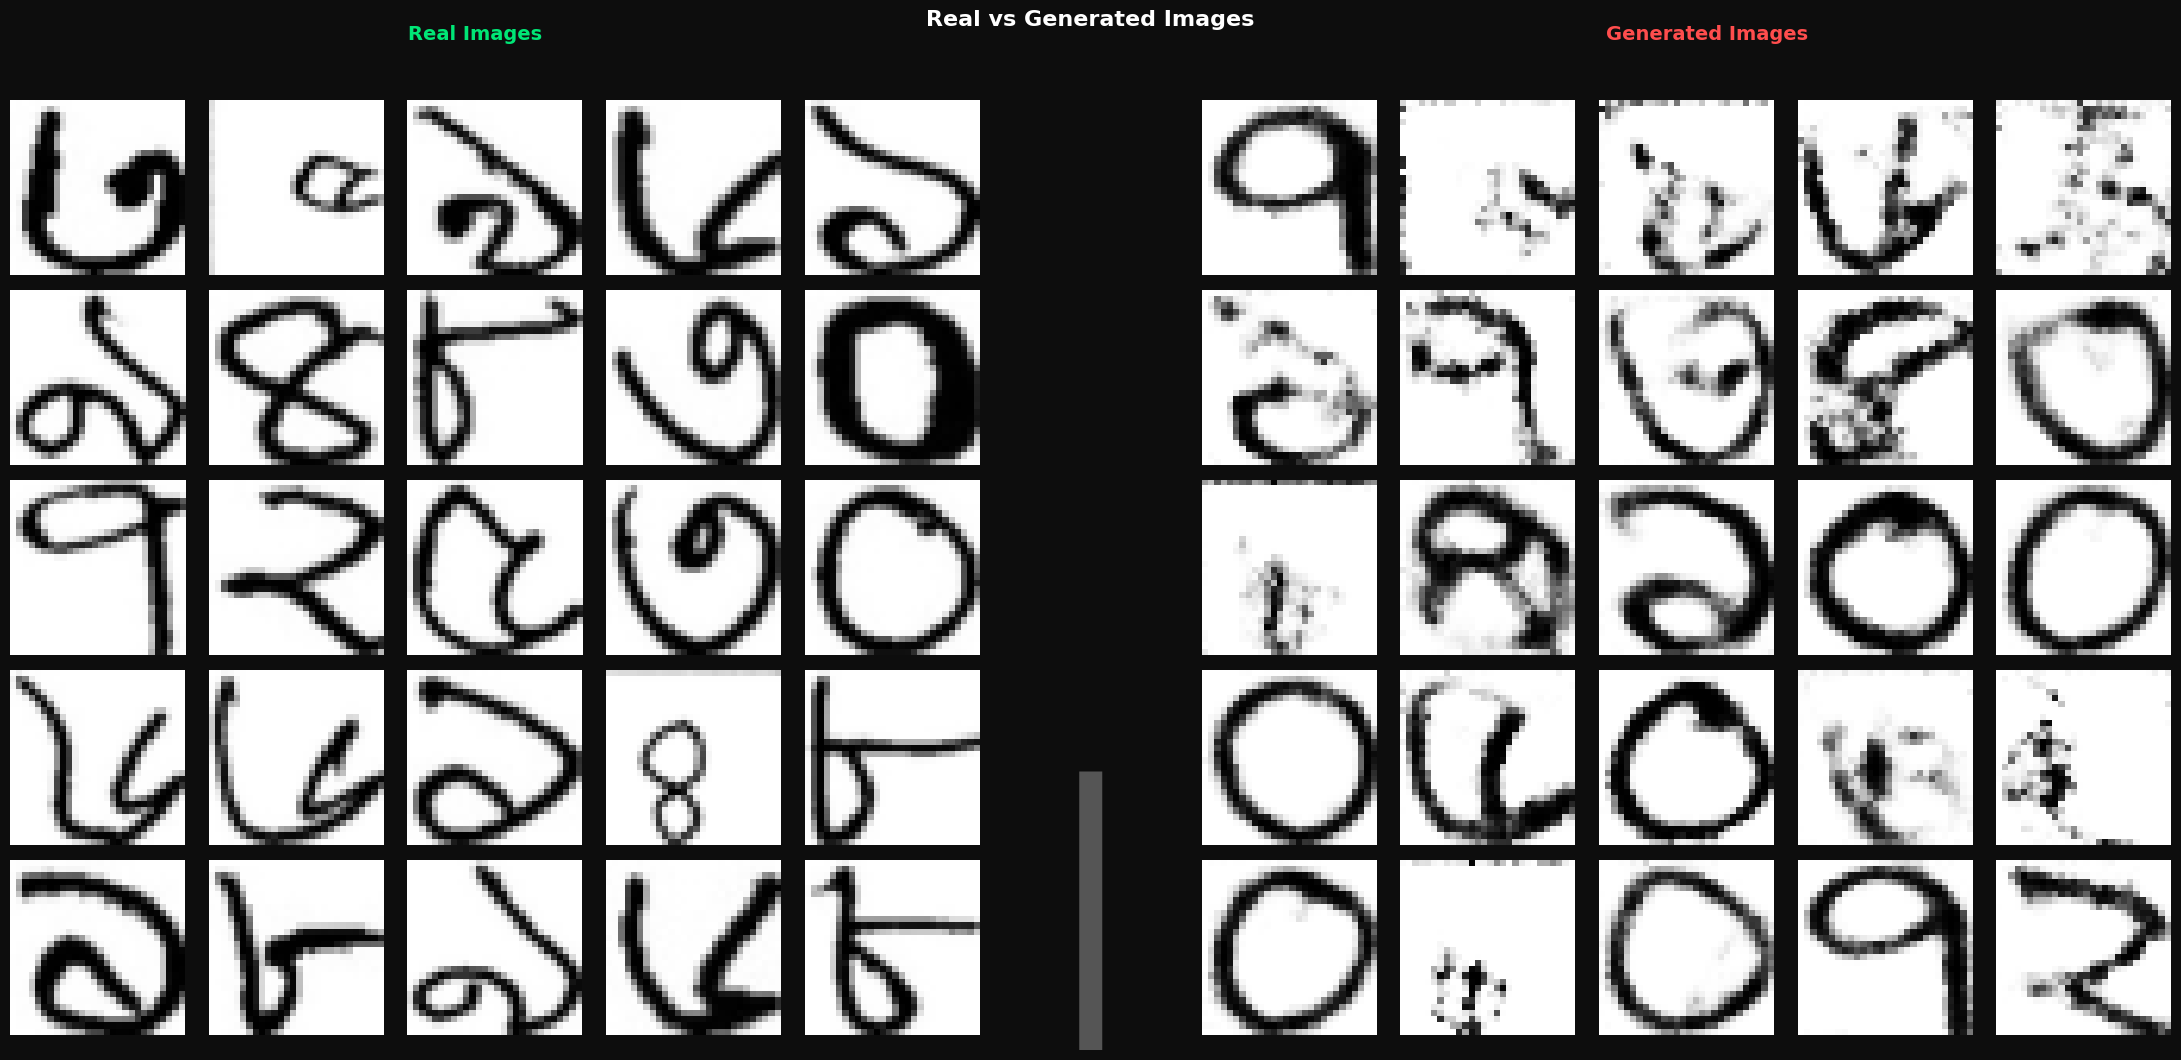

In [20]:
G.eval()
with torch.no_grad():
    z = torch.randn(25, LATENT_DIM, device=DEVICE)
    fake_imgs = G(z).cpu()

real_imgs_sample = get_real(25)

fig = plt.figure(figsize=(22, 10))
fig.patch.set_facecolor('#0d0d0d')

for i in range(25):
    ax = fig.add_subplot(5, 11, (i // 5) * 11 + (i % 5) + 1)
    real = denorm(real_imgs_sample[i]).squeeze().numpy()
    ax.imshow(real, cmap='gray')
    ax.axis('off')

for i in range(25):
    ax = fig.add_subplot(5, 11, (i // 5) * 11 + (i % 5) + 7)
    fake = denorm(fake_imgs[i]).squeeze().numpy()
    ax.imshow(fake, cmap='gray')
    ax.axis('off')

fig.text(0.22, 1.01, 'Real Images',  color='#00e676', fontsize=14, fontweight='bold', ha='center')
fig.text(0.78, 1.01, 'Generated Images', color='#ff4d4d', fontsize=14, fontweight='bold', ha='center')
fig.text(0.5,  0.0,  '|',           color='white',   fontsize=200, ha='center', va='bottom', alpha=0.3)

plt.suptitle('Real vs Generated Images', color='white', fontsize=16, fontweight='bold', y=1.04)
plt.tight_layout()
plt.show()

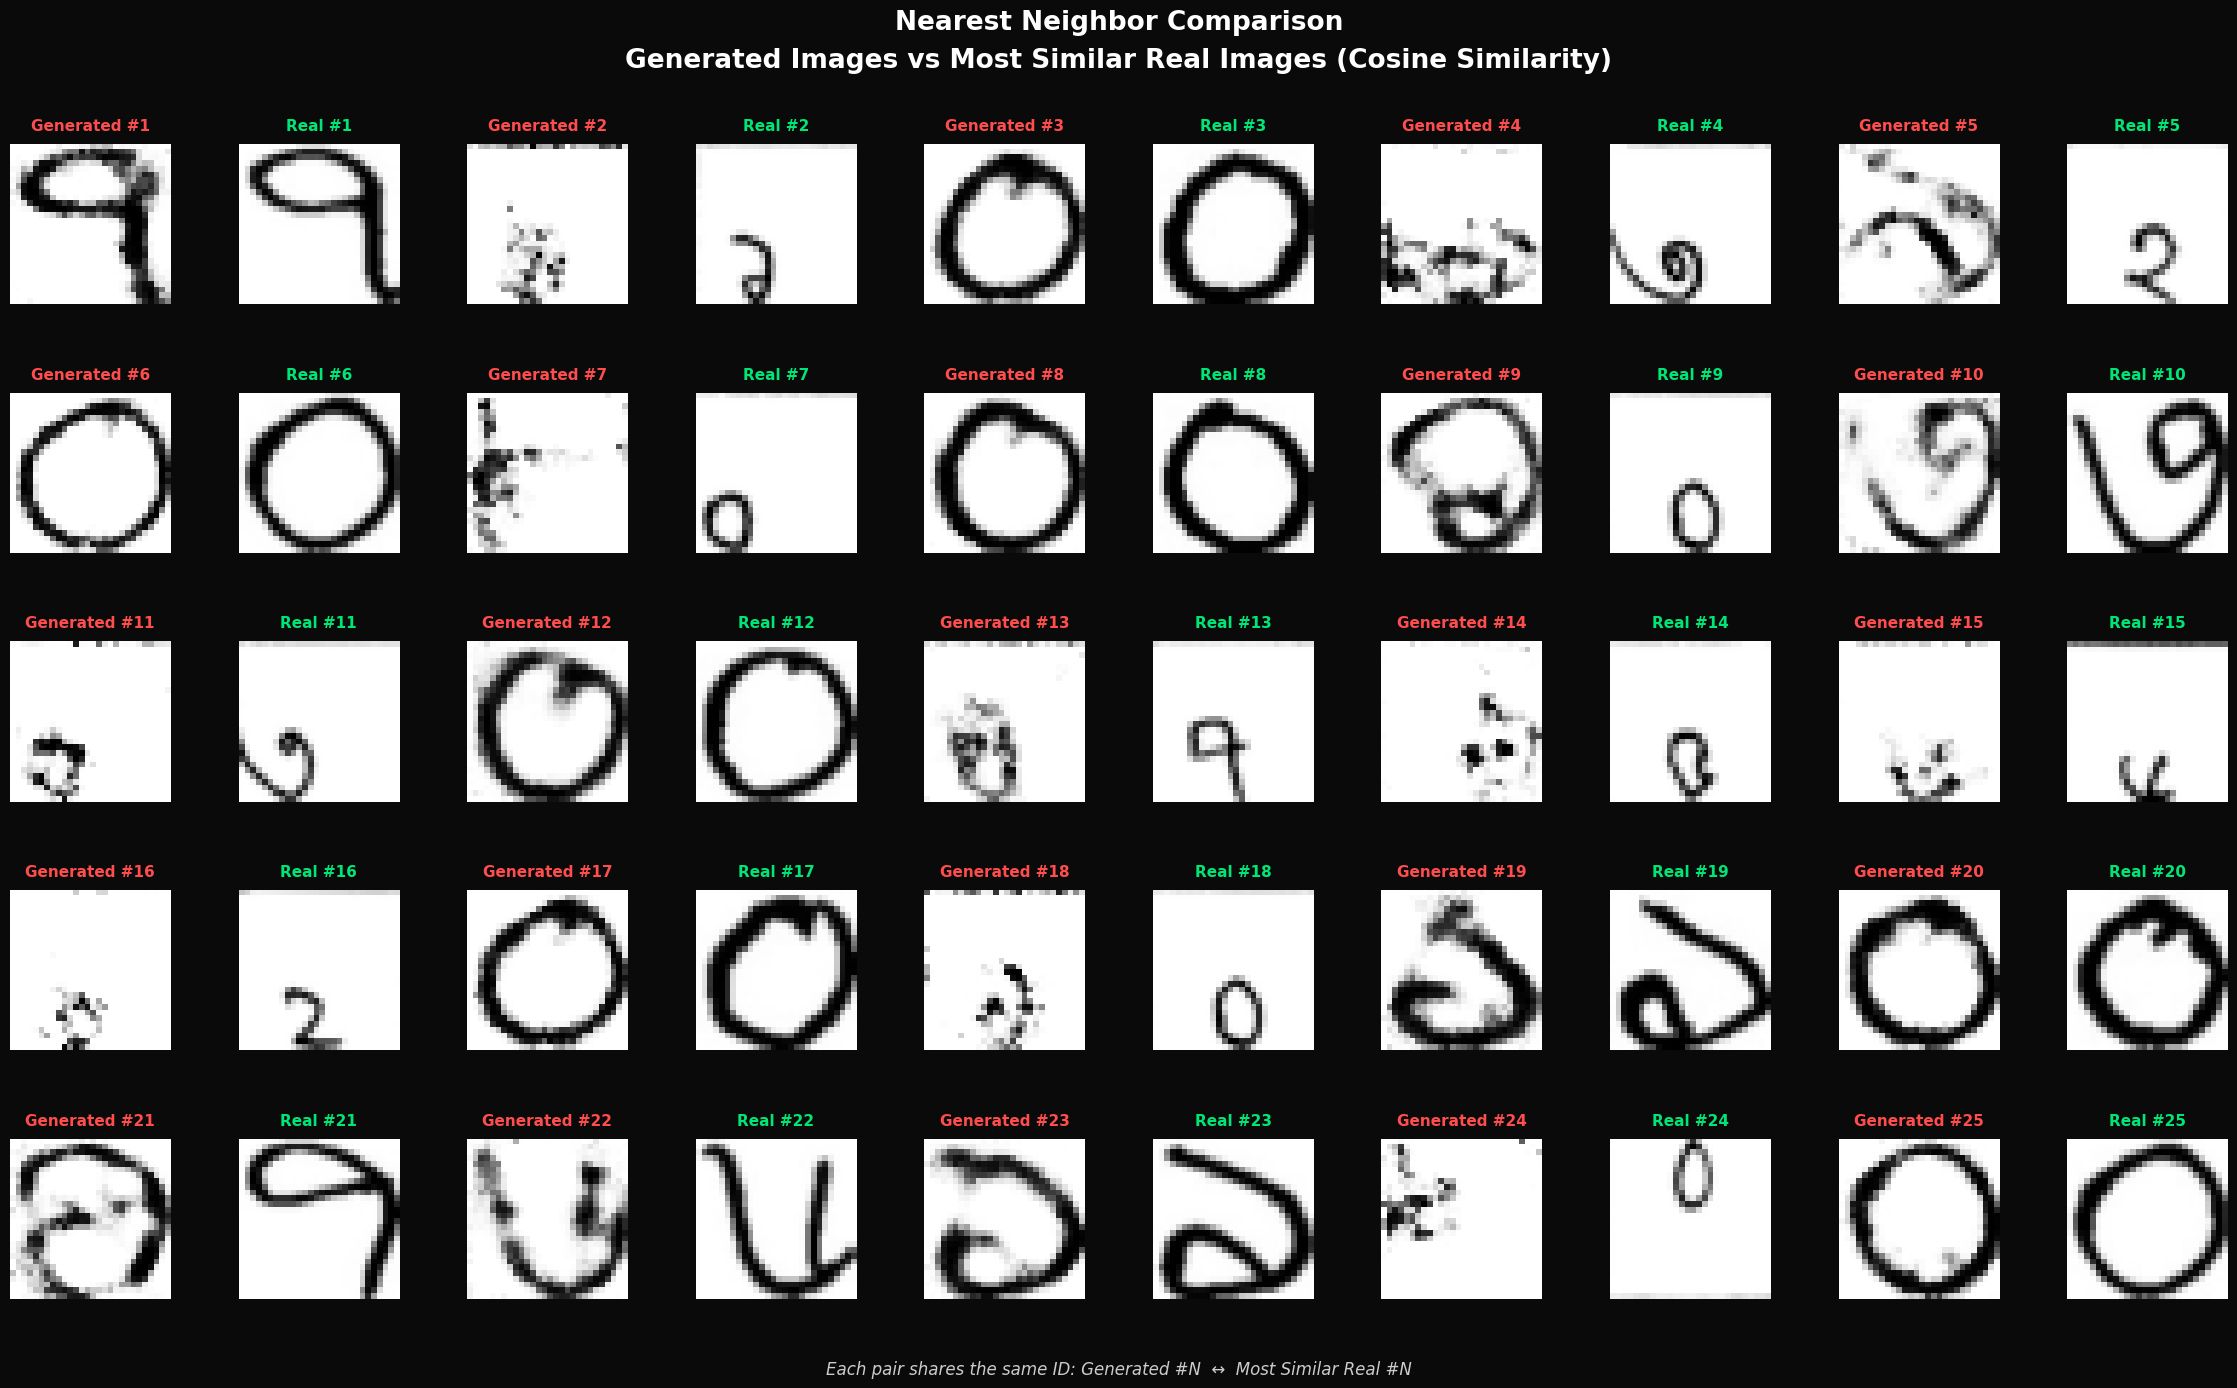

In [21]:
# Generate fake images
G.eval()
with torch.no_grad():
    z = torch.randn(25, LATENT_DIM, device=DEVICE)
    fake_imgs = G(z).cpu()

real_imgs_sample = get_real(500)

# Compute nearest neighbors
fake_flat = denorm(fake_imgs).view(25, -1).numpy()
real_flat = denorm(real_imgs_sample).view(500, -1).numpy()

sims = cosine_similarity(fake_flat, real_flat)
nn_indices = sims.argmax(axis=1)
nn_real = real_imgs_sample[nn_indices]

# ====================== Clean Professional Visualization ======================
fig, axes = plt.subplots(5, 10, figsize=(24, 15), facecolor='#0a0a0a')
plt.subplots_adjust(hspace=0.55, wspace=0.15, top=0.85, bottom=0.08, left=0.03, right=0.97)

for i in range(25):
    row = i // 5
    col = (i % 5) * 2
    pair_id = i + 1

    fake = denorm(fake_imgs[i]).squeeze().numpy()
    real = denorm(nn_real[i]).squeeze().numpy()

    # Generated
    ax1 = axes[row, col]
    ax1.imshow(fake, cmap='gray')
    ax1.axis('off')
    ax1.set_title(f'Generated #{pair_id}', color='#ff4d4d', fontsize=11, fontweight='bold', pad=10)

    # Real with same ID
    ax2 = axes[row, col + 1]
    ax2.imshow(real, cmap='gray')
    ax2.axis('off')
    ax2.set_title(f'Real #{pair_id}', color='#00e676', fontsize=11, fontweight='bold', pad=10)

# Suptitle with extra gap
plt.suptitle(
    'Nearest Neighbor Comparison\n'
    'Generated Images vs Most Similar Real Images (Cosine Similarity)',
    color='white', 
    fontsize=19, 
    fontweight='bold', 
    y=0.94,
    linespacing=1.6
)

# Footer
fig.text(0.5, 0.03,
         'Each pair shares the same ID: Generated #N  ↔  Most Similar Real #N',
         ha='center', fontsize=12, color='#cccccc', style='italic')

plt.show()